# Jupyter Notebook setup

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

sns.set_theme(style ='whitegrid', palette ='muted')

In [2]:
state_df = pd.read_csv(r"C:\Users\HP\Desktop\Code Basics\Resume Project\RPC12_Input_For_Participants\RPC12_Input_For_Participants\datasets\electric_vehicle_sales_by_state.csv")
maker_df = pd.read_csv(r"C:\Users\HP\Desktop\Code Basics\Resume Project\RPC12_Input_For_Participants\RPC12_Input_For_Participants\datasets\electric_vehicle_sales_by_makers.csv")
date_df  = pd.read_csv(r"C:\Users\HP\Desktop\Code Basics\Resume Project\RPC12_Input_For_Participants\RPC12_Input_For_Participants\datasets\dim_date.csv")


In [3]:
state_df.head(), maker_df.head(), date_df.head()

(        date   state vehicle_category  electric_vehicles_sold  \
 0  01-Apr-21  Sikkim       2-Wheelers                       0   
 1  01-Apr-21  Sikkim       4-Wheelers                       0   
 2  01-May-21  Sikkim       2-Wheelers                       0   
 3  01-May-21  Sikkim       4-Wheelers                       0   
 4  01-Jun-21  Sikkim       2-Wheelers                       0   
 
    total_vehicles_sold  
 0                  398  
 1                  361  
 2                  113  
 3                   98  
 4                  229  ,
         date vehicle_category         maker  electric_vehicles_sold
 0  01-Apr-21       2-Wheelers  OLA ELECTRIC                       0
 1  01-Apr-22       2-Wheelers      OKAYA EV                       0
 2  01-May-21       2-Wheelers  OLA ELECTRIC                       0
 3  01-Jun-21       2-Wheelers  OLA ELECTRIC                       0
 4  01-Jul-21       2-Wheelers  OLA ELECTRIC                       0,
         date  fiscal_year qua

In [4]:
print("State data shape:", state_df.shape)
print("Maker data shape:", maker_df.shape)
print("Date data shape:", date_df.shape)

State data shape: (2445, 5)
Maker data shape: (816, 4)
Date data shape: (36, 3)


In [5]:
state_df.info()
maker_df.info()
date_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2445 entries, 0 to 2444
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   date                    2445 non-null   object
 1   state                   2445 non-null   object
 2   vehicle_category        2445 non-null   object
 3   electric_vehicles_sold  2445 non-null   int64 
 4   total_vehicles_sold     2445 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 95.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   date                    816 non-null    object
 1   vehicle_category        816 non-null    object
 2   maker                   816 non-null    object
 3   electric_vehicles_sold  816 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 25.6+ KB
<class 'pand

# Null values & data quality checks

In [6]:
state_df.isnull().sum()
maker_df.isnull().sum()
date_df.isnull().sum()

date           0
fiscal_year    0
quarter        0
dtype: int64

### Now check logical nulls:

In [7]:
(state_df['electric_vehicles_sold'] < 0).sum()
(state_df['total_vehicles_sold'] < 0).sum()


0

# Duplicates check

In [8]:
state_df.duplicated().sum()
maker_df.duplicated().sum()


0

# Question 1
## List the top 3 and bottom 3 makers for FY 2023 and FY 2024 in terms of number of 2-wheelers sold

### Inspect maker data

In [9]:
maker_df.head()
maker_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   date                    816 non-null    object
 1   vehicle_category        816 non-null    object
 2   maker                   816 non-null    object
 3   electric_vehicles_sold  816 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 25.6+ KB


In [10]:
date_df.head()
date_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         36 non-null     object
 1   fiscal_year  36 non-null     int64 
 2   quarter      36 non-null     object
dtypes: int64(1), object(2)
memory usage: 996.0+ bytes


# Convert date column properly 

In [11]:
maker_df['date'] = pd.to_datetime(maker_df['date'], format='%d-%b-%y')
date_df['date']  = pd.to_datetime(date_df['date'], format='%d-%b-%y')


In [12]:
maker_df['date'].min(), maker_df['date'].max()


(Timestamp('2021-04-01 00:00:00'), Timestamp('2024-03-01 00:00:00'))

In [13]:
date_df['date'].min(), date_df['date'].max()

(Timestamp('2021-04-01 00:00:00'), Timestamp('2024-03-01 00:00:00'))

# Bring fiscal year into maker_df

In [14]:
maker_df = maker_df.merge(
    date_df[['date', 'fiscal_year']],
    on='date',
    how='left'
)


In [15]:
maker_df[['date', 'fiscal_year']].head()

,date,fiscal_year
0,2021-04-01,2022
1,2022-04-01,2023
2,2021-05-01,2022
3,2021-06-01,2022
4,2021-07-01,2022


In [16]:
maker_df['fiscal_year'].isna().sum()

0

# Standardize fiscal_year

In [17]:
maker_df['fiscal_year'] = maker_df['fiscal_year'].astype(str)


In [18]:
maker_df['fiscal_year'].unique()

array(['2022', '2023', '2024'], dtype=object)

# Filtering for the Q1 solution

In [19]:
q1_df = maker_df[
    (maker_df['vehicle_category'] == '2-Wheelers') &
    (maker_df['fiscal_year'].isin(['2023', '2024']))
]


In [20]:
q1_df.shape

(312, 5)

In [21]:
q1_df[['maker', 'fiscal_year']].drop_duplicates().head()

,maker,fiscal_year
1,OKAYA EV,2023
380,OLA ELECTRIC,2023
381,OKINAWA,2023
382,HERO ELECTRIC,2023
383,AMPERE,2023


In [22]:
q1_summary = (
    q1_df
    .groupby(['fiscal_year', 'maker'], as_index=False)
    ['electric_vehicles_sold']
    .sum()
)


In [23]:
q1_summary.head()

,fiscal_year,maker,electric_vehicles_sold
0,2023,AMPERE,87376
1,2023,ATHER,76921
2,2023,BAJAJ,32797
3,2023,BEING,11018
4,2023,HERO ELECTRIC,88993


# Rank top & bottom 3

In [24]:
def top_bottom(df, year):
    data = df[df['fiscal_year'] == year] \
        .sort_values('electric_vehicles_sold', ascending=False)
    return data.head(3), data.tail(3)

top_3_2023, bottom_3_2023 = top_bottom(q1_summary, '2023')
top_3_2024, bottom_3_2024 = top_bottom(q1_summary, '2024')


In [25]:
plot_df = pd.concat([
    top_3_2023, bottom_3_2023,
    top_3_2024, bottom_3_2024
])


# Visualization plots

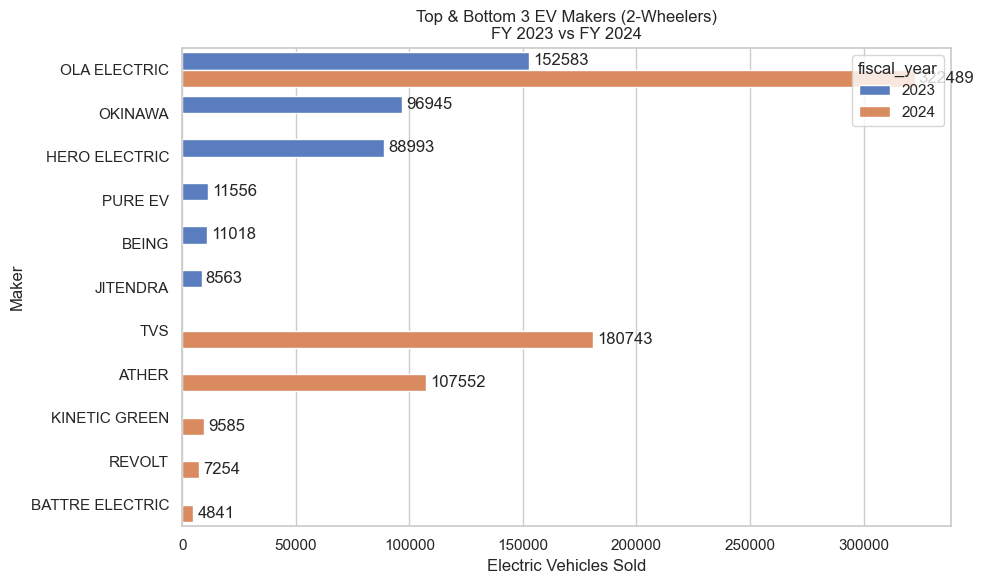

In [26]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=plot_df,
    x='electric_vehicles_sold',
    y='maker',
    hue='fiscal_year'
)

plt.title("Top & Bottom 3 EV Makers (2-Wheelers)\nFY 2023 vs FY 2024")
plt.xlabel("Electric Vehicles Sold")
plt.ylabel("Maker")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.0f',          # no decimals
        label_type='edge',   # label at end of bar
        padding=3            # space between bar and label
    )

    
plt.tight_layout()
plt.show()

# Question 2
## Identify the top 5 states with the highest penetration rate in 2-wheeler and 4-wheeler EV sales in FY 2024.

Penetration rate = EVs sold ÷ Total vehicles sold

We compare states, not makers

We split by vehicle category

Only FY 2024

In [27]:
state_df['date'] = pd.to_datetime(state_df['date'], format='%d-%b-%y')
date_df['date']  = pd.to_datetime(date_df['date'], format='%d-%b-%y')

state_df = state_df.merge(
    date_df[['date', 'fiscal_year']],
    on='date',
    how='left'
)

state_df['fiscal_year'] = state_df['fiscal_year'].astype(str)


In [28]:
state_df['fiscal_year'].unique()

array(['2022', '2023', '2024'], dtype=object)

## Normalize vehicle_category

In [29]:
state_df['vehicle_category'] = (
    state_df['vehicle_category']
    .str.strip()
    .str.lower()
)


In [30]:
state_df['vehicle_category'].unique()

array(['2-wheelers', '4-wheelers'], dtype=object)

## Calculate penetration rate

In [31]:
state_df['penetration_rate'] = (
    state_df['electric_vehicles_sold'] /
    state_df['total_vehicles_sold']
) * 100


In [32]:
state_df['penetration_rate'].describe()

count    2445.000000
mean        2.222389
std         9.633795
min         0.000000
25%         0.092272
50%         0.815376
75%         2.485614
max       447.560976
Name: penetration_rate, dtype: float64

### Filter for FY 2024 only

In [33]:
q2_df = state_df[state_df['fiscal_year'] == '2024']
q2_df.shape

(814, 7)

In [34]:
q2_df.head()

,date,state,vehicle_category,electric_vehicles_sold,total_vehicles_sold,fiscal_year,penetration_rate
48,2023-04-01,Sikkim,2-wheelers,0,465,2024,0.0
49,2023-04-01,Sikkim,4-wheelers,0,439,2024,0.0
50,2023-05-01,Sikkim,2-wheelers,0,507,2024,0.0
51,2023-05-01,Sikkim,4-wheelers,0,448,2024,0.0
52,2023-06-01,Sikkim,2-wheelers,0,517,2024,0.0


## Aggregate at state + vehicle category level

Why aggregation?

Data is monthly

We want overall FY 2024 penetration

In [35]:
q2_summary = (
    q2_df
    .groupby(['state', 'vehicle_category'], as_index=False)
    .agg({
        'electric_vehicles_sold': 'sum',
        'total_vehicles_sold': 'sum'
    })
)

q2_summary['penetration_rate'] = (
    q2_summary['electric_vehicles_sold'] /
    q2_summary['total_vehicles_sold']
) * 100


## Get top 5 states for each category

In [36]:
top_5_states = (
    q2_summary
    .sort_values('penetration_rate', ascending=False)
    .groupby('vehicle_category')
    .head(5)
)


In [37]:
top_5_states

,state,vehicle_category,electric_vehicles_sold,total_vehicles_sold,penetration_rate
20,Goa,2-wheelers,9768,54290,17.992264
34,Kerala,2-wheelers,64769,478887,13.524903
32,Karnataka,2-wheelers,148111,1279767,11.573279
40,Maharashtra,2-wheelers,183052,1817343,10.072507
18,Delhi,2-wheelers,38094,405218,9.400866
35,Kerala,4-wheelers,9169,159227,5.758445
13,Chandigarh,4-wheelers,1020,22651,4.503112
19,Delhi,4-wheelers,8630,201130,4.290757
33,Karnataka,4-wheelers,12878,302221,4.261120
21,Goa,4-wheelers,1031,24234,4.254353


## Visualization

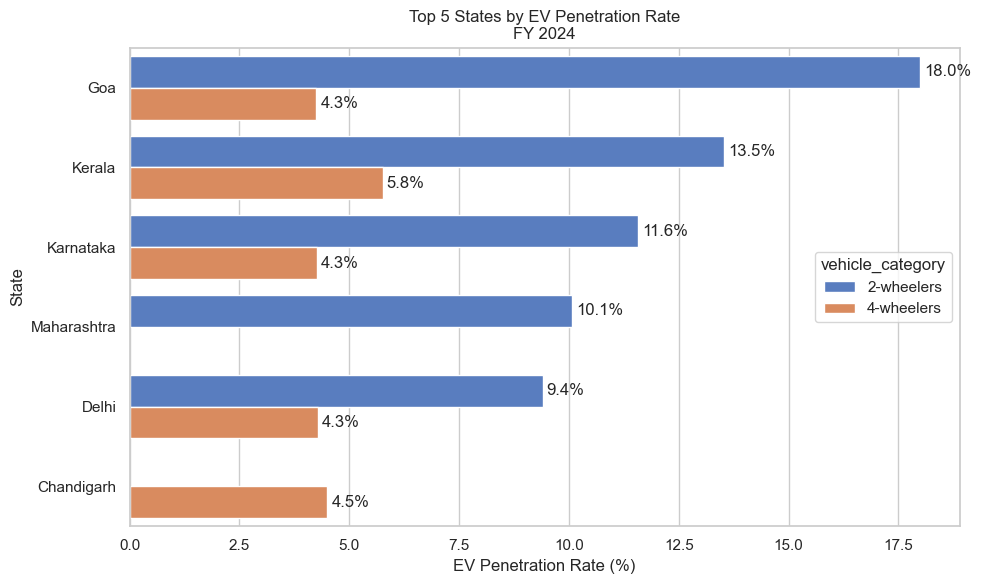

In [38]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=top_5_states,
    x='penetration_rate',
    y='state',
    hue='vehicle_category'
)

plt.title("Top 5 States by EV Penetration Rate\nFY 2024")
plt.xlabel("EV Penetration Rate (%)")
plt.ylabel("State")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='edge',
        padding=3
    )

plt.tight_layout()
plt.show()

# Question 3
# List the states with negative penetration (decline) in EV sales from 2022 to 2024?

“Negative penetration (decline) in EV sales” does NOT mean

EV sales went down

Or EV penetration was low

It means: EV penetration rate in 2024 is LOWER than in 2022

So a state can still sell more EVs, but if total vehicle sales grew faster, penetration can decline.

We will:

Calculate penetration for FY 2022

Calculate penetration for FY 2024

Compare 2024 – 2022

Identify negative change

In [39]:
state_df['fiscal_year'].unique()

array(['2022', '2023', '2024'], dtype=object)

In [40]:
state_df['vehicle_category'].unique()

array(['2-wheelers', '4-wheelers'], dtype=object)

## Aggregate sales by State & Year 
We must sum first, then calculate penetration.

In [41]:
yearly_state_sales = (
    state_df
    .groupby(['state', 'fiscal_year'], as_index=False)
    .agg({
        'electric_vehicles_sold': 'sum',
        'total_vehicles_sold': 'sum'
    })
)

## Calculate penetration rate

In [42]:
yearly_state_sales['penetration_rate'] = (
    yearly_state_sales['electric_vehicles_sold'] /
    yearly_state_sales['total_vehicles_sold']
) * 100


In [43]:
yearly_state_sales.head()

,state,fiscal_year,electric_vehicles_sold,total_vehicles_sold,penetration_rate
0,Andaman & Nicobar,2024,2,660,0.303030
1,Andaman & Nicobar Island,2022,22,5148,0.427350
2,Andaman & Nicobar Island,2023,23,6534,0.352005
3,Andaman & Nicobar Island,2024,33,6543,0.504356
4,Andhra Pradesh,2022,13928,772748,1.802399


# Pivot for comparison (THIS is the key move)

We want:

One column for 2022

One column for 2024

In [44]:
penetration_pivot = yearly_state_sales[
    yearly_state_sales['fiscal_year'].isin(['2022', '2024'])
].pivot(
    index='state',
    columns='fiscal_year',
    values='penetration_rate'
).reset_index()


In [45]:
penetration_pivot.columns = ['state', 'penetration_2022', 'penetration_2024']
penetration_pivot.head()

,state,penetration_2022,penetration_2024
0,Andaman & Nicobar,NaN,0.303030
1,Andaman & Nicobar Island,0.427350,0.504356
2,Andhra Pradesh,1.802399,4.238662
3,Arunachal Pradesh,0.000000,0.111143
4,Assam,0.192384,0.638575


## Calculate change in penetration

In [46]:
penetration_pivot['penetration_change'] = (
    penetration_pivot['penetration_2024'] -
    penetration_pivot['penetration_2022']
)
penetration_pivot.head()

,state,penetration_2022,penetration_2024,penetration_change
0,Andaman & Nicobar,NaN,0.303030,NaN
1,Andaman & Nicobar Island,0.427350,0.504356,0.077005
2,Andhra Pradesh,1.802399,4.238662,2.436263
3,Arunachal Pradesh,0.000000,0.111143,0.111143
4,Assam,0.192384,0.638575,0.446191


Is it logically correct to compare states that didn’t exist in 2022? - No

So we must restrict the analysis only to states with data in BOTH years.

## Explicitly filter states that have both years

In [47]:
penetration_pivot_clean = penetration_pivot.dropna(
    subset=['penetration_2022', 'penetration_2024']
).copy()

In [48]:
penetration_pivot_clean.shape

(34, 4)

In [49]:
penetration_pivot_clean['penetration_change'] = (
    penetration_pivot_clean['penetration_2024'] -
    penetration_pivot_clean['penetration_2022']
)
penetration_pivot_clean.head()

,state,penetration_2022,penetration_2024,penetration_change
1,Andaman & Nicobar Island,0.427350,0.504356,0.077005
2,Andhra Pradesh,1.802399,4.238662,2.436263
3,Arunachal Pradesh,0.000000,0.111143,0.111143
4,Assam,0.192384,0.638575,0.446191
5,Bihar,0.540838,1.330358,0.789519


## Identify states with negative penetration

In [50]:
negative_states = penetration_pivot_clean[
    penetration_pivot_clean['penetration_change'] < 0
]


In [51]:
negative_states

,state,penetration_2022,penetration_2024,penetration_change


### Conclusion : An analysis of EV penetration trends between FY 2022 and FY 2024 shows that no Indian state with continuous data experienced a decline in EV penetration rate. While some states lacked data for FY 2022 and were excluded from comparison, all comparable states demonstrated stable or increasing EV adoption relative to total vehicle sales.

# Question 4
## What are the quarterly trends based on sales volume for the top 5 EV makers (4-wheelers) from 2022 to 2024?

## Deleting old column "fiscal_year" to avoid data over riding 

In [52]:
maker_df = maker_df.drop(columns=['fiscal_year'], errors='ignore')

In [53]:
maker_df = maker_df.merge(
    date_df[['date', 'fiscal_year', 'quarter']],
    on='date',
    how='left'
)


In [54]:
maker_df.columns

Index(['date', 'vehicle_category', 'maker', 'electric_vehicles_sold',
       'fiscal_year', 'quarter'],
      dtype='object')

In [55]:
maker_df[['date', 'fiscal_year', 'quarter']].head()


,date,fiscal_year,quarter
0,2021-04-01,2022,Q1
1,2022-04-01,2023,Q1
2,2021-05-01,2022,Q1
3,2021-06-01,2022,Q1
4,2021-07-01,2022,Q2


## Quarterly trends based on sales volume for the top 5 EV makers (4-wheelers), FY 2022–FY 2024

We’ll move in 4 clean steps:

Filter correct data

Identify top 5 makers

Build quarterly trend table

Visualize + interpret

## Filter to 4-Wheelers & required years

In [56]:
maker_df['vehicle_category'] = (
    maker_df['vehicle_category']
    .str.strip()
    .str.lower()
)

In [57]:
maker_df['vehicle_category'].unique()

array(['2-wheelers', '4-wheelers'], dtype=object)

In [58]:
maker_df['fiscal_year'] = maker_df['fiscal_year'].astype(int)

In [59]:
maker_df['fiscal_year'].unique()

array([2022, 2023, 2024])

In [60]:
fw_df = maker_df[
    (maker_df['vehicle_category'] == '4-wheelers') &
    (maker_df['fiscal_year'].isin([2022, 2023, 2024]))
]

In [61]:
fw_df.shape

(360, 6)

In [62]:
fw_df[['maker', 'fiscal_year']].drop_duplicates().head()

,maker,fiscal_year
9,BYD India,2022
10,PCA Automobiles,2022
11,BMW India,2022
12,Volvo Auto India,2022
13,KIA Motors,2022


## Identify the TOP 5 4-Wheeler EV makers (2022–2024 combined)

In [63]:
top_5_makers = (
    fw_df
    .groupby('maker', as_index=False)['electric_vehicles_sold']
    .sum()
    .sort_values('electric_vehicles_sold', ascending=False)
    .head(5)
)

top_5_makers

,maker,electric_vehicles_sold
8,Tata Motors,88935
5,Mahindra & Mahindra,41193
4,MG Motor,13753
1,BYD India,2419
2,Hyundai Motor,2076


In [64]:
top_5_list = top_5_makers['maker'].tolist() # Store them: This avoids misleading trend comparisons caused by changing participants.
top_5_list

['Tata Motors',
 'Mahindra & Mahindra',
 'MG Motor',
 'BYD India',
 'Hyundai Motor']

### Build QUARTERLY sales data for these makers

In [65]:
quarterly_trends = (
    fw_df[fw_df['maker'].isin(top_5_list)]
    .groupby(['fiscal_year', 'quarter', 'maker'], as_index=False)
    ['electric_vehicles_sold']
    .sum()
)

In [66]:
quarterly_trends['fy_quarter'] = (
    quarterly_trends['fiscal_year'].astype(str) + " " +
    quarterly_trends['quarter']
)

In [67]:
quarterly_trends.head()

,fiscal_year,quarter,maker,electric_vehicles_sold,fy_quarter
0,2022,Q1,BYD India,0,2022 Q1
1,2022,Q1,Hyundai Motor,25,2022 Q1
2,2022,Q1,MG Motor,285,2022 Q1
3,2022,Q1,Mahindra & Mahindra,355,2022 Q1
4,2022,Q1,Tata Motors,1031,2022 Q1


## Visualization – Quarterly trend lines

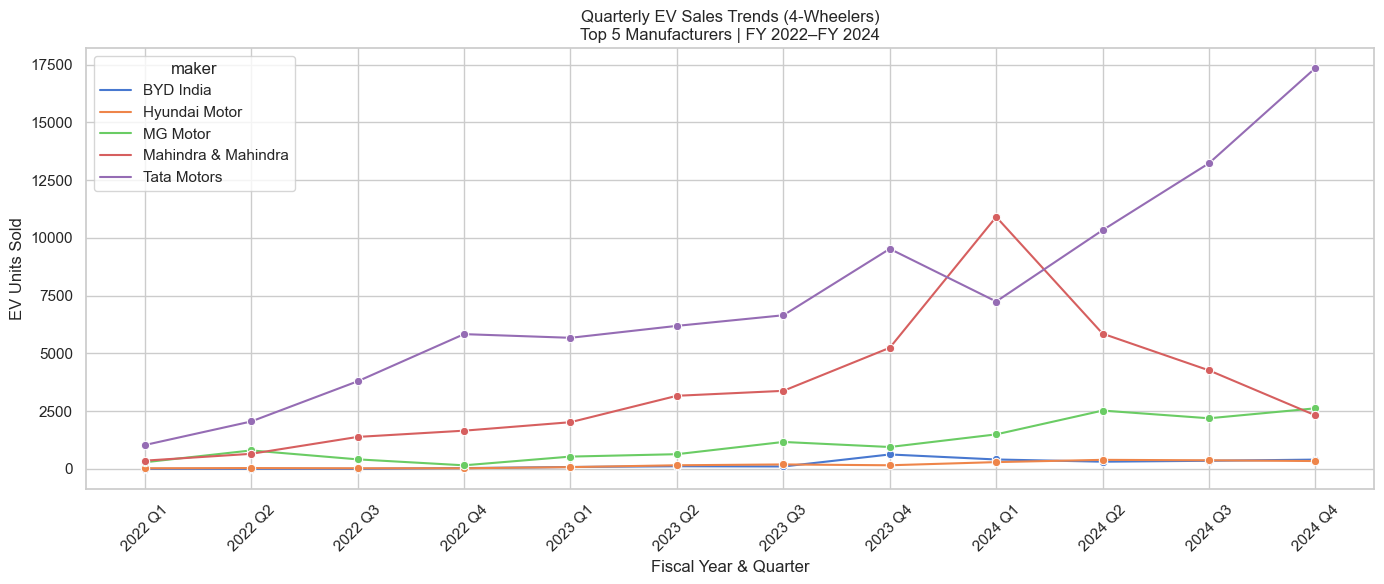

In [68]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=quarterly_trends,
    x='fy_quarter',
    y='electric_vehicles_sold',
    hue='maker',
    marker='o'
)

plt.title(
    "Quarterly EV Sales Trends (4-Wheelers)\n"
    "Top 5 Manufacturers | FY 2022–FY 2024"
)
plt.xlabel("Fiscal Year & Quarter")
plt.ylabel("EV Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



# Question 5 
## How do the EV sales and penetration rates in Delhi compare to Karnataka for 2024?

This is a comparative market-readiness question, not just a ranking exercise.

We must compare two dimensions:

Absolute EV sales → market size

Penetration rate → adoption intensity

Both are needed for a business decision.

## We’ll create a derived DataFrame just for Q5.

In [69]:
q5_df = state_df[
    (state_df['fiscal_year'] == '2024') &
    (state_df['state'].isin(['Delhi', 'Karnataka']))
]


In [70]:
q5_df['state'].value_counts()

state
Delhi        24
Karnataka    24
Name: count, dtype: int64

## Aggregate sales & penetration
Sum first, then compute penetration.

In [71]:
q5_summary = (
    q5_df
    .groupby('state', as_index=False)
    .agg({
        'electric_vehicles_sold': 'sum',
        'total_vehicles_sold': 'sum'
    })
)

q5_summary['penetration_rate'] = (
    q5_summary['electric_vehicles_sold'] /
    q5_summary['total_vehicles_sold']
) * 100

In [72]:
q5_summary

,state,electric_vehicles_sold,total_vehicles_sold,penetration_rate
0,Delhi,46724,606348,7.705806
1,Karnataka,160989,1581988,10.176373


# Visualization

## EV Sales comparison (market size)

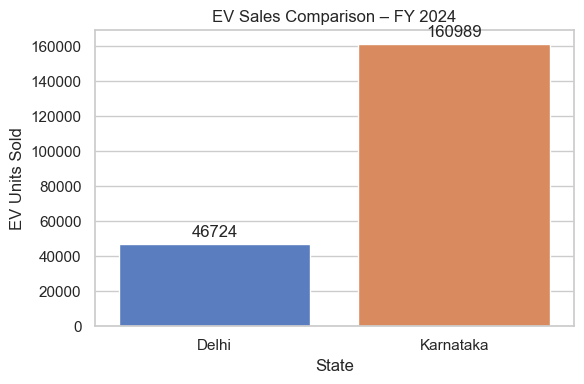

In [73]:
plt.figure(figsize=(6,4))
ax1 = sns.barplot(
    data=q5_summary,
    x='state',
    y='electric_vehicles_sold'
)

plt.title("EV Sales Comparison – FY 2024")
plt.ylabel("EV Units Sold")
plt.xlabel("State")

for container in ax1.containers:
    ax1.bar_label(container, fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()

## Penetration rate comparison (adoption intensity)

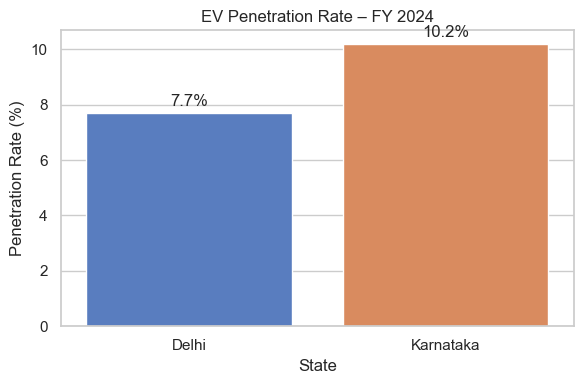

In [74]:
plt.figure(figsize=(6,4))
ax2 = sns.barplot(
    data=q5_summary,
    x='state',
    y='penetration_rate'
)

plt.title("EV Penetration Rate – FY 2024")
plt.ylabel("Penetration Rate (%)")
plt.xlabel("State")

for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f%%', padding=3)

plt.tight_layout()
plt.show()

# Question 6 
## List down the compounded annual growth rate (CAGR) in 4-wheeler units for the top 5 makers from 2022 to 2024.


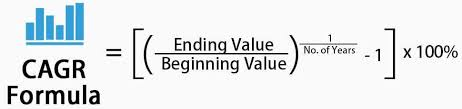

In [75]:
from IPython.display import Image
Image(url='data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQABAAD/2wCEAAkGBw8RERUTEBIVFRUVGBUVGBUXFxcXFxoVFhUXGRUWHRoYHiggGBolHRgYITEhJSkrOi8uFx8zODMsNygtLisBCgoKDg0OGhAQGzclHyM3NSs2NjY1LSs3Ny0tNzcvLS0tNy0tLiswNS0tLi8tLS8tKy0tKy0tLTc1LS0tMy0tLf/AABEIAG0BzgMBIgACEQEDEQH/xAAcAAEAAgMBAQEAAAAAAAAAAAAABQYDBAcBAgj/xABPEAACAQMDAQMHBQoKCAcAAAABAgMABBEFEiEGEzFBBxQiMlFxsiMzYYGRJDRCUnJ1kqGz0jZFU2JzgoOTsdQVFhc1VFV00QhWY7TBwtP/xAAZAQEBAQEBAQAAAAAAAAAAAAAABAUDAQL/xAAtEQEAAQMCAwUIAwAAAAAAAAAAAQIDEQQxEiFhExQiQVEjMjOBwdHh8KGxwv/aAAwDAQACEQMRAD8A7ZSlKBSlKBmlUnyi+tD7n/xWvfJ2wAnLEADs+ScD8Kqe7+x7TKPvft+yx8/5XWlY1uIycB1J9gYGslT4VxMTshL7qm2hkaN9+5Tg4XI7gf8A5qN1zqp4xE9uFKSKzempz6LY8DVa6r+/Jvyh8C01f73tPyJP2hrTt6W34Jnnn7Ma7rLs8dMcsfdc+ktZluhIZAo2lQNoI7857yfZU/VO8nXqze9P8Gq41FqaYpuTEbNHR1zXZpqq3KUpXBSUpSgUpSgUpSgUpSgUpSgUpSgUpSgUpSgUpSgUpSgUpSgUpSgUpSgUpSgUpSgUpSgUpSgUpSgUpSgUpSgUpSgUpSgUpSgVo3Gs2sbFZJUVh3qTyK365f1f9+S+9fgWqNNZi7XwzKTWaibNEVRCU68uUk7B42DKRJgju4K5qN0r7yvP7H46xaj962v9t8YrLpX3nef2PxmtGmnhsxT6T9WTXXNd6ap84/y96KA88T3P8Brplcy6NP3Wn5MnwNWC31i7Mi5nk5Zfwz7a5anTzduzidod9JqqbNqImN5n6Prqv78m/KHwrTVvmLT+jk/aGnVf35N+UPgWmrfMWn9HJ+0NU0e7b/fJJX713984WLyc+rN70/warhVP8nPqze9P8Gq4Vl6v41Ta0PwKSlKVMrKUpQKVCdWdQiwiSTsXmMkscCohUMXkyF5bjvGPrrRXqTUSQDo9wPpM1tx9PD0FppSlApSlApSlApSlApSlApSlApSlApSlApSlApSlApSlApSlApSlApSlApSlApVYl6j1AMQNIuGAJAYTWwBAPBGXzzW10j1H5+kzdi8LQTPbujlWIeMDdyvHecfVQTtKUoFKUoFKUoFKUoFKUoFcw6vP3ZL71+Fa6fUFqVpqDSMYHiCcYDKCe7nwNU6W52deUettdpREf1zUrUfvW1/tvjFZtIGbO7A5+Z+M1ZvMtW/lIP0V/dotpq47pYR/VH7tVTf8OMxvnfrn0Qxp54uLE7Y26Y9Va6QjYXa5Uj0ZPA/iGou2ibtF9FvWXwP4wq9+bax/LQ/YP3aeb6x/LQ/YP3a+u8TxTVy59fw87r4YpxPKc7flUeqz92TflD4FrzVj8haf0cn7Q1bTZat/KQfoj92vPMtW/lYP0R+7XkX8RTHLl1+XoTppmapxPPp1z6tXyc+rN70/warjUdokNyqt5yyE5GNgA48c4AqRqG/XxXJlqaajgtRSUpSuLuUpSgpnlR+asvzhZfGauhql+VH5qy/OFl8Zq6GgrPV/UUtu0FtaKkl3cvtjVwSixrzLM+0g7FHsPJ91WOMHA3EE+JAwM+PGTj7TVF6J+7NS1C/blY38xg/mpFgykflMQftq+UCtfUL2OCJ5pW2xxq0jtgnCqMscAEngHurYqB6+/wB133/S3H7JqD60bq2yu3EcDyMxUsN0E8alR47pEC+PtqczVP0SfUxZAzpbJGtplHillaXcIhsJVo1A454Y81XrW9vobfSLxryaU3c1pBLE+zsjHcIRkALkOuM7s5Jz7qDp00oVSx7lBJ9wGTUXp3UlpP5uEc7rmNpolKsC0aY3HuwuNw4J8arLm5vZtRPncsCWrdjFGmwLxCHaSQMDvDFu7jgcYPNaPR95Kv8AoKJXYRyWlyXQH0WKRxbMjxxk/bQdLzTNcnlu9QGnXd+L6YPbXFwI4/RMZSO4YbHBG58gkZzwAuB4myGS4vdSuIBcy28drDbsBEVDPLcBm3ksp3KoUDb3ZPNBcpZAqlj3AEnAJOAMnAHJP0Vo2+uW0lr54kgNvsaXtMMBsUEscEbuMHjGeKh/JpeTTWCSXEhkk7W5UufHbcSKPcAAAB4CqXMjR21zoyeiZL9YI9oxttLr7pZh9CoJR9VB1XT7yOeJJYjuSRVdDgrlGAKnDAEZBB5Fa95q8MVxBbuT2lwJTGAMgiFQz5PhwwqmdZ6gytNHYve9rawBitu0KW8GEZozJ2pG8lcHYN3orwB4lvnuL3p+eTG6W2u5Gx3bntYGP6zQdCzTNcxttYuTo1vKZpO1a+WJn3HcUN+6bCfZsAGPZX3q2rX1xdXqQrf/AHOwig8183Eaydkr75e1cGTLMPRwRtA8c0HS6GtLQ5pntoWuE2TNGhkT8WTaN44+nNb1BV26imh1MWd0qCK4XdayqCNzr85C+WI3+IIwCMeJqz1UPKppjS6dJLHxNalbqJh3h4jubGPau4fZUrpmpz3VtBcW4i2zRJIe0LAhmAJA2jw5H1UE1Sq5Y67NMI2ie2YSs6J8+MtGGLg5X0cbT34/WKkQb/8AFtvtl/7UEmKh9AvJpHukmZWMNwI1KqUGw21vKAQWbJBlIznnAr6mnvkUs3moVQWJLS4AAySeO7FRltqUiHcot0NyHny63KbuyjjVmbeg2kIqcHBIUkAgE0FopUPa3V7IiyILfa6qy57ZThhkZVlBU89xArLuv/ZbfbL/ANqCTpWlaNdbvlhCFwfUL7s+HrDGK3qDylKUHoqk+TDv1P8AOd58Qq7CqT5MP4z/ADnefEKC60pmmaBSoWDqi0e78zjctMA5ICtsGwgON+MFgSMgZxmtfV+r4LeV4hHPM0Sh5uxj3iFCCQznI8AThcnHhQWKlV++6vtk7IRLLcvNH2yJbpvYw8fKncQFXnxOT4A19x9W2jQxTRl5BOWCIkbGQmPPaAp3rt2nOfZ45FBO0qNi1y3eOCSNi63JXssA5YMpfODgqAoJOcYxjv4qSoFKUoFKEgAk8Ac1zOXyl3V1O8GjWJuhH607uEj78ZGcDB8MkE+AoOm0qudIanqU4kGo2a2zIVC7ZA4cHOSME4AwPHxqr9f+VVdMvBai3EuER3btNpUsT6O3acnbg9/4VB0ulYkmVkDgjaQGDeG0jOfdiuazeU26u53h0WxN0Iz6Uzvsj78cdwx7MsM47qDp9Kq3R+ratPJImo2K2wQAq6SBw5JIwME92M9/s4qtJ5SdQmurq3stL7fzWR43PnCqfRd0DYZR37DwM0HTaVUOg+u4tTMsZheC4g+chc5xyRkHA7jwQQMcVb6Aa5v1tc6Wt2wutYvLSTamYYZZEjAxwwCoRk955rpFfLRKeSqn3gGg42b3Qv8AzFqX9/N/+VdX0BozawGKVpo+zTZK5Jd12jDsSASSOeRW32Ef4i/oisgAHA4oKZ5UfmrL84WXxmrjO2FJ9gJ+wVTvKj81ZfnCy+M1c3XPHt4oKJ5EhnSInPrSSTux9pMzAn9VWPVdceB9i2V3OMBt8KwlOSRtzJKpzxnu8RVa8ix2ae9sfWtbm4gYHvBD7v8A7VfaCt/61Tf8q1D9C2/zFauq609xDJBJpWo7JUaNsLbA7XBDYPnHBwar/Uuq28ep3QvLm8jjjt7d41t3uQAx7TexWH0R3L6/FTGg9R3KWVksy+dXlysjKEeMAohJ7R5AdoAQxhiM+k3AoI+yiMXAs9cZdjR7Hkt2TayFPVM+MgHj3Cs0gQwWsB0vVNlnJDLFxa53wAiPce39Ic8jjNS79axLbySyQyLLFMLVrYFWkNw23YisDtYMGBDez3V96b1LLLeeZTWr28pt2uCTIrrtDog2sg9Lljzxgr3cg0EDqEEM07ztpWqq0oVZVQwIkoXhRIouMPxx9I4ORWSw2Qm0KaXqmbOOSKLItT6EgUNu+X9I4Uc06f6w2WWnbYbidrsTIgaVZJi0W4+m7BQ2cHLHGAPGpBuuQlteSzWzxyWTIssJdScPtKsrrkFSrZHHhQRzKhtJrP8A0XqnZTtI78Wu7Mr73we34GforzVG7aUTjS9USUR9lvjeGIyJziOTbPyufHvGTU7p/VLPdR209rLbmdHkgZ2Rg6x4LghSTG4BB2nwqGsurFtbYOUuJ+01GezAaQSSby0pXaSANuU2qhxgMOeKDH0Ne3NjZR28ml3xZTIx2LblAZJGfapacEgbsZIHdWWR42vlvzpOpduidmDi2249IBtvb+sAzDPsNS9l1cu65W7he2e1jE7hmWQGEhjvUp3+qQR7eOa1YOtJS1qJLCaJbyQJEzvH6rIzZdVyUbAzs+nv4IoIvUYIZ5ZJW0vVVMyqkyxtAiSqo2rvVbj0iBx7uDxWa3dUazZdL1TNjG8UORa+o8axnd8v6R2ovsqT8olzLbR293HIyrb3ERmUMQrQSN2cm4A4IG4Nz3YrFfXc0urrHEZDHZ2rzSRo+0STTnbDGwyFJ2ozDdwM54oIJ9KtiSf9FasAZRcBA0HZpMHDl1Q3GFJI5+gnGM1uXpWWdp103V4ZJAFkaFoI+0C8LuAuMEgcbsZx41YNK6kd7vzS5tjBKYzMnyiSqyKwDAlfVYbhxj3E1AdFa4YbS0R1Mhuby7g3FuVxNOwPIO4YTGOKCai6mlVQo0vUTgAZK2xPAxyTcZJ+mvo9VTf8q1H9C2/zFfZ6piV78SqUSw7Mu+c7leES8LjgjOMc5Nead1JI08UNzavbm4V2hLOj7tgDMjBfUk2nOOe488UE3fRCSJ1I4ZGBB9hUjBqn+RectotqW5x2q/UszgfqxVo6gvRBazzNwI4pH/RQmq/5JLIw6PaKe9kMn1Su0g/UwoNIdK3irH2DrGTDMHbPzdyYHiimXAychlz/AES48anNFtLiF2IiWOKRkHZ9sW7MLG2+QZXBLPtG3I7txOSRVgpQUrUunbuUTqdpLi9+UMhPaRzI4t4CmMKIyyc+HZZHrnErrehLNbQwpGvyclu2PVAjWRROo98RlXHiGI8asFKCp3mjXhuZpkYk+m0GXAiwbbs1hkAXf2faEvhTjOG78ivnS9AnVo+1HoJPJKE3jAUwpsGEAXAlDNtAwODz31bqUEP0rYSwQdnIBwx2ktukKbVwZGHDSE7ssO8YJ5zUpPOiDLsqjuyxCjPs5rJWtf6fBOu2eKOVQQwWRFcAjIzhgQDyefpoMyuGXKMCD3MCCPePA1TejI5o9S1KGS5mnEa2JBlbOGkjlLlVACoCQOFA7hVxtreONVSNFRF4VVAVQPYAOAPdULpOjyxahfXLFezuVtQgBJYdgjq+4YwOWGME93hQT4qk+TD+M/znefEKuwqk+TD+M/znefEKD68pLvAttdW2TdRzBIYhn5cScSQso7xty2T6u3Nb3k7WM2EcqSmZpy00kh72mc/KDH4O05Xb4bamZtLheaOd0DSRBxGxJ9EPgPgZxkgAZxmmmaXBbhxAmwSO0rAFiDI/rMAThc+wYFBX9UGNbssf8LefFDWHpSeOO51cTEArcCVt38gbePYTn8HCt+urPLpsLTJOy5ljV0VsnhXxvGM45wO8eFaerdMWN04kuLdJHAC7iDkqOQrYI3ryfRbIoOfeRxWjkVZvXfT7Z4s+MQnnJxnwG5M+8Vt9HaXcSGW8tmi9C+1Pslk3dm1vO8YOCvIIeLIPPAI8ci86r07Z3QQTwI/Z8IcFSoPeoKkEKQBkdxraGnQiDzdUCRbezCJ6ACEYKjbjHHsoOfaBFOklnHDInpwzpDM8e5ewh7NppFQMMGeV1I9I4jiTxJq79L6m11aQzuoVnU7gM7dysVYrnnaSMj6CKyajottOqJLGCsfKYypX0dvospBX0SRgHkHHdW5bW6RoscahEQBVVQAoUDAAA7gBQZKUpQV3yizOml3rISGEEgBHeMjBP2E1BeQu2jXR4mQANI8zOfEsJGQZ/qqoq8X9mk8UkUgykiMjD2qwIP6jXI9B0nX9CeSG2thf2jsXUBwjKT488oTxkYI4zQdidgASTgDkn2Y8a/Na39jfLrFzdTxpLPjzZHJDERtvQD+qkafbXVbq/wBau9OvVbTzbzOoihTtkLESZWRixIxtBJHdWx5PehYLXT4o7u1hac7mk3xxuwZmJ27sHOBgcHwoK7o+vtcdKTMp+Uggktm55ATCg/3TKakfJHmDQFltoe1lPnEhjB2mSRZGVVzzj0VUZrW8nnRl1Zy6jaXMObG43dm25CCuWUeiDuBZGHePwK0On9K17Qnkht7YX9o7F0AkCMrcc88qSAMjBBIzQWXpHygXF5qD2FxYm1kjjMjZlDnjZhcBQOQ4Oc1QuktcurPUtZe2sZLsmeTcEYLs2zzYJGCTnJ7h4VZuhdH1N9buNSu7M20c0JQK0iOQwEKgcHJ4jJ7hW/5N+nby11HVJriLZHczF4m3Idy9tM2cKSRwynn20ET5Ek87mvNTkkQzTvsaJQR2YJ3c578gLjH4p5znHWq5x0N01eWOr37dl9yXJLpIGTG7fvVdoO4eu6934NdHoFKUoFKUoKZ5UfmrL84WXxmroapflRSQwWzRxSS9ne2srLEjSNsjYljtUE91bS9cwkgeZ6jye82UwH1nHAoIm2J07W5Fbi31PDofwVu4xhk9gLjnv5OBV/qO17RLe9i7K4UlQyuCrFWV1OVZWXBUj2it+NcADJP0nvP00FRns9Qh1G5ube3jmWeGCNd0wj2tFvzuG0kqd/h7Kgv9nkqQ2heK2u3hNyZYHysRFzIJCIiQdpQjjI5ye6um0oKFfdKk2ieb2tvZzQ3UN3HErgxu8XADsqjBYMy9x8KaTcXEmvl5o0jKaeVKJJ2hQtcoVDtgDcdrEAeA+mrrqFhDcRtFPGkkbYyjqGU4ORkH2EA/VWHSdGtbVStrBHCpOSI1C5Pdk47/AK6CldNdK3cEejrIqg2RuzNhgcdqkipj8blh3V71F0tdzDWRGqnz0WghyyjPZRIr7vxcEHvroVe0Fa1bSppNR0+4VR2dut2JDkAgzRRqmB3nlT3VX/8AVW87KBdq5j1g3zDev3uXlbP5WHHo10SvaCma70zLdXN6WISK4sUtlfIOJA8jZK5zgbgfpxUNfzX5n0iG7jgR0uAfk5e0MnZ28gaVV2jYmOec8tjwyekyxqwKsAQQQQRkEEYIIPeKjNK6asLVy9tawxOQQWSNVbae8ZAzjgcfQKDP1Bpq3VtNbv3TRvH7ty4B+o4NU/RemdRGnXgldI7+7GO0VjhezhSKIb15HCE5HdvNX6lBz/prpeaG+t7jzK3tY44JYnETh3Z27PDudo35IODyfaecD4tul76OztOzWMz2t5Nc9kz4V0kkm9HeMhW2yA/VXQ6UFDHSl3cJqq3WyM34i2FG3qhSLYAe4nBVcnAzzis/S3TYhlRpNKs7eRAc3EMgJ3YIyi7AwBBPeeMnvq60oKL5Tbh5xDpcJPa3rjeR+BbRkNLIeOAcbR7eau1tCsaKiDCooVR7FUYA+ytG00KCO5lugCZpVVGdmLYRfVRQeEX6B3nk81J0HlKUoFKUoFKUoFKUoFKUoPRVJ8mH8Z/nO8+IVvS9bwqxXzPUDgkZFnMQcHGQQOR9NaPkuWTZfO8UsQmv7mZFljaNjHIVZTtYA9x/UaC60pSgUpSgUpSgUpSg8dwoJPcASfcO+qN/tf0H/im/uZ/3Kul782/5D/Ca4P5IOtdMsLKSK83b2nZxiIyegYolHIHHKtxQdx0bVYbuBJ7dt0UgJVsFcgEg8MARyDW9VB626/Sz0+CeyQO93gW6spAwRksVGD4jj2sKr+ua/wBR6QkV1eyQXMDsqyxLGEMRYZ2hlAJ8cMc8ig69Xlc48qPXNzYRWU1kEdbgk4dS25NqMgGCCCQ3h7aw6jrOvafpNxd3rwGffCYkVQVjR2VWRgAMnn2t76DptK4nqvV/Ulva2+qSNb+bSFfucIPUcZRmYjcNwH4LcZHHgPvXur+orKK21G4aDza4ZR5qqD0FdS6KWI3bigPO7gjkUHaq8rn/AJR+r7myfT/Ndm27kKvvXcduYcY54OHP6qyeUXqu6sbzTobfZsupTHJuXcdvaQr6PPBw5/VQTF/1jBDqMOnNHIZZ0Dq4C9mB8p35bdn5M+HiKslcn6o/hbp3/T/5urD1ZDrhlc219a2luFUxl0VnZtvpBjICoG7xHhjjxIXelUbyTdXz6lbS+che2gk7NmQYVgRlWx3A8MOOOB7cVeaBSlKD2ma8pQKUpQKUpQKUpQKUpQKUpQKUpQKUpQKUpQKUpQKUpQKUpQKUpQKUpQKUpQKUpQe0rylApSlApSlApSlApSlBhvfm3/If4TXMP/DqoOmzZA++n8P/AEYMV1WvFQDuAHuoOXeXbTJjFaXkKFxZSM7qB3Ixjbcf5oMQBPhuzUL5SuuLfVrOKz04NNNcPGzIFbMYXwORjO7HPcACa7YRWGGziQkpGik95VQCfeQOaDkHlesjBDo0JOTE6Rk+3YsK5/VVr8uH+5bj8qD9ulXhowe8A16yg94zQce69/gnaf0dj+zFZPLD/B6z/KtP/bvXXSgxjAx7PChQEYIGPZQcf8tUTra6XdKpZLd1LY/nLEy5PgD2ZGfaRUN151haalqOlNaFmjhnTdIUZV3STQnZ6QGSAvPvrvDxqwwwBB4wRkfZXxFbRqNqIqgeAUAfYKDlnVP8LdP/AKD/ADdVy/u7I67enX9xSLd5tEwcoUDegAF7yVwQO4knPdXetgznAz7cc1iltImILRoxHcSoJHuJHFByf/w9OpW/wuwGaMhPFVIkwPq7vqrr1eKgHcAK9oFKUoFKUoFKUoFKUoFKUoFKUoFKUoFKUoFKUoFKUoFKUoFKUoFKUoFKUoFKUoFKUoFKUoFKUoFKUoFKUoFKUoFKUoP/2Q==')


Where:

Beginning Value = FY 2022 total sales

Ending Value = FY 2024 total sales

n = number of years = 2 (2022 → 2024)

We do NOT use quarterly values directly for CAGR. We must use annual totals.

## Filter 4-wheelers for 2022–2024

In [76]:
cagr_df = maker_df[
    (maker_df['vehicle_category'] == '4-wheelers') &
    (maker_df['fiscal_year'].isin([2022, 2023, 2024]))
]

In [77]:
cagr_df.shape

(360, 6)

## Identify top 5 makers

In [78]:
q6_top_5_makers_4w = (
    cagr_df
    .groupby('maker', as_index=False)['electric_vehicles_sold']
    .sum()
    .sort_values('electric_vehicles_sold', ascending=False)
    .head(5)
)

q6_top_5_makers_4w_list = q6_top_5_makers_4w['maker'].tolist()
q6_top_5_makers_4w_list


['Tata Motors',
 'Mahindra & Mahindra',
 'MG Motor',
 'BYD India',
 'Hyundai Motor']

## Create annual sales table

In [79]:
q6_annual_sales_4w = (
    cagr_df[cagr_df['maker'].isin(q6_top_5_makers_4w_list)]
    .groupby(['maker', 'fiscal_year'], as_index=False)
    ['electric_vehicles_sold']
    .sum()
)

In [80]:
q6_annual_sales_4w

,maker,fiscal_year,electric_vehicles_sold
0,BYD India,2022,33
1,BYD India,2023,920
2,BYD India,2024,1466
3,Hyundai Motor,2022,110
4,Hyundai Motor,2023,576
5,Hyundai Motor,2024,1390
6,MG Motor,2022,1647
7,MG Motor,2023,3277
8,MG Motor,2024,8829
9,Mahindra & Mahindra,2022,4042


## Pivot to wide format (required for CAGR)
We want one row per maker with sales by year.

In [81]:
q6_cagr_pivot_4w = (
    q6_annual_sales_4w
    .pivot(index='maker', columns='fiscal_year', values='electric_vehicles_sold')
    .reset_index()
)

In [82]:
q6_cagr_pivot_4w.columns = ['maker', 'sales_2022', 'sales_2023', 'sales_2024']
q6_cagr_pivot_4w

,maker,sales_2022,sales_2023,sales_2024
0,BYD India,33,920,1466
1,Hyundai Motor,110,576,1390
2,MG Motor,1647,3277,8829
3,Mahindra & Mahindra,4042,13805,23346
4,Tata Motors,12708,28046,48181


## Handle CAGR edge cases
CAGR is undefined if sales in 2022 = 0.
We must explicitly protect against that.

In [83]:
q6_cagr_pivot_4w = q6_cagr_pivot_4w[
    q6_cagr_pivot_4w['sales_2022'] > 0
].copy()

## Calculate CAGR (correct formula) - Time period = 2 years (2022 → 2024)

In [84]:
q6_cagr_pivot_4w['cagr_2022_2024 (%)'] = (
    (q6_cagr_pivot_4w['sales_2024'] / q6_cagr_pivot_4w['sales_2022']) ** (1/2) - 1
) * 100

In [85]:
q6_cagr_result = (
    q6_cagr_pivot_4w[['maker', 'cagr_2022_2024 (%)']]
    .sort_values('cagr_2022_2024 (%)', ascending=False)
).round(2)

q6_cagr_result

,maker,cagr_2022_2024 (%)
0,BYD India,566.52
1,Hyundai Motor,255.48
3,Mahindra & Mahindra,140.33
2,MG Motor,131.53
4,Tata Motors,94.71


# Question 7. 

## List down the top 10 states that had the highest compounded annual growth rate (CAGR) from 2022 to 2024 in total vehicles sold.

Here we’re not talking EVs only, but overall vehicle market momentum by state. That’s crucial for manufacturing location and long-term scale decisions.

Metric: Total vehicles sold (EV + non-EV)

Level: State

Period: FY 2022 → FY 2024

CAGR years (n) = 2

### Why this matters: A state with fast total-vehicle growth is a future demand engine, even if EV penetration is currently low.

## Aggregate annual total vehicle sales by state

In [86]:
q7_annual_state_sales = (
    state_df
    .groupby(['state', 'fiscal_year'], as_index=False)
    ['total_vehicles_sold']
    .sum()
)

In [87]:
q7_annual_state_sales.head()

,state,fiscal_year,total_vehicles_sold
0,Andaman & Nicobar,2024,660
1,Andaman & Nicobar Island,2022,5148
2,Andaman & Nicobar Island,2023,6534
3,Andaman & Nicobar Island,2024,6543
4,Andhra Pradesh,2022,772748


## Keep only FY 2022 and FY 2024

In [88]:
q7_filtered = q7_annual_state_sales[
    q7_annual_state_sales['fiscal_year'].isin(['2022', '2024'])
]

In [89]:
q7_filtered.head(10)

,state,fiscal_year,total_vehicles_sold
0,Andaman & Nicobar,2024,660
1,Andaman & Nicobar Island,2022,5148
3,Andaman & Nicobar Island,2024,6543
4,Andhra Pradesh,2022,772748
6,Andhra Pradesh,2024,782865
7,Arunachal Pradesh,2022,19929
9,Arunachal Pradesh,2024,27892
10,Assam,2022,379450
12,Assam,2024,547626
13,Bihar,2022,892873


## Pivot to wide format (required for CAGR)

In [90]:
q7_pivot = (
    q7_filtered
    .pivot(index='state', columns='fiscal_year', values='total_vehicles_sold')
    .reset_index()
)

q7_pivot.columns = ['state', 'sales_2022', 'sales_2024']
q7_pivot.head()

,state,sales_2022,sales_2024
0,Andaman & Nicobar,NaN,660.0
1,Andaman & Nicobar Island,5148.0,6543.0
2,Andhra Pradesh,772748.0,782865.0
3,Arunachal Pradesh,19929.0,27892.0
4,Assam,379450.0,547626.0


In [91]:
q7_pivot = q7_pivot[q7_pivot['sales_2022'] > 0].copy() # NaN - No sales in 2022 → CAGR is undefined
q7_pivot.head()

,state,sales_2022,sales_2024
1,Andaman & Nicobar Island,5148.0,6543.0
2,Andhra Pradesh,772748.0,782865.0
3,Arunachal Pradesh,19929.0,27892.0
4,Assam,379450.0,547626.0
5,Bihar,892873.0,1132703.0


## Calculate CAGR (correct formula)

In [92]:
q7_pivot['cagr_2022_2024'] = (
    (q7_pivot['sales_2024'] / q7_pivot['sales_2022']) ** (1/2) - 1
) * 100

In [93]:
q7_pivot['cagr_2022_2024'] = q7_pivot['cagr_2022_2024'].round(2)

## Get TOP 10 states by CAGR

In [94]:
q7_top_10_states = (
    q7_pivot
    .sort_values('cagr_2022_2024', ascending=False)
    .head(10)
)

q7_top_10_states

,state,sales_2022,sales_2024,cagr_2022_2024
22,Meghalaya,22193.0,36628.0,28.47
10,Goa,48372.0,78524.0,27.41
16,Karnataka,1007894.0,1581988.0,25.28
9,Delhi,401540.0,606348.0,22.88
28,Rajasthan,880985.0,1300476.0,21.50
11,Gujarat,1094872.0,1590987.0,20.55
4,Assam,379450.0,547626.0,20.13
23,Mizoram,19439.0,27422.0,18.77
3,Arunachal Pradesh,19929.0,27892.0,18.30
12,Haryana,528591.0,732029.0,17.68


## Visualization

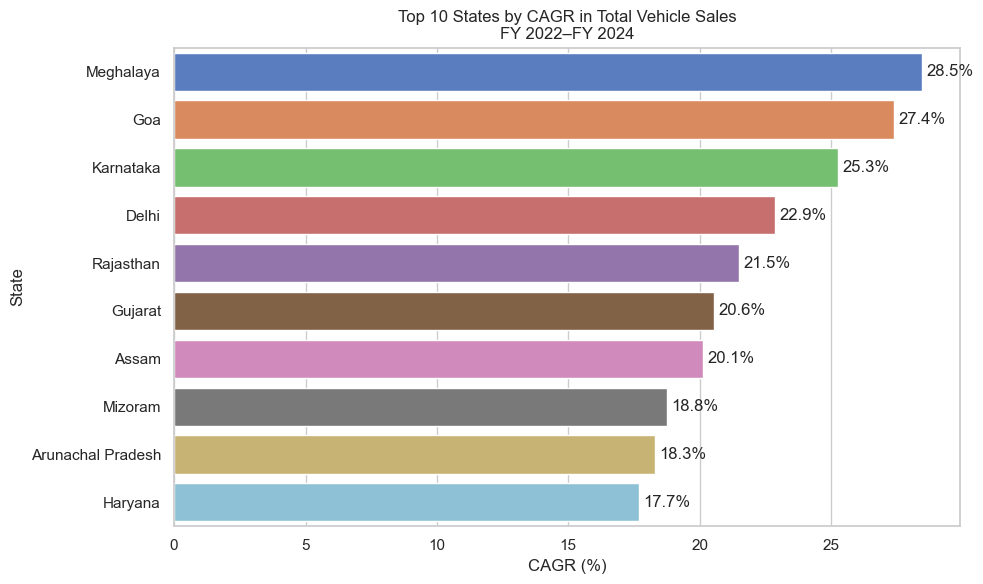

In [95]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=q7_top_10_states,
    x='cagr_2022_2024',
    y='state'
)

plt.title(
    "Top 10 States by CAGR in Total Vehicle Sales\nFY 2022–FY 2024"
)
plt.xlabel("CAGR (%)")
plt.ylabel("State")

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.tight_layout()
plt.show()

# Question 8 
## What are the peak and low season months for EV sales based on the data from 2022 to 2024?
We are not comparing years

We are not comparing states or makers

We want overall EV demand seasonality

In [96]:
q8_df = state_df.copy() # We’ll create a derived DataFrame only

## Extract month from date

In [97]:
q8_df['month'] = q8_df['date'].dt.month
q8_df['month_name'] = q8_df['date'].dt.month_name()

## Aggregate EV sales by month (across 2022–2024)

In [98]:
q8_monthly_sales = (
    q8_df
    .groupby(['month', 'month_name'], as_index=False)
    ['electric_vehicles_sold']
    .sum()
)

In [99]:
q8_monthly_sales = q8_monthly_sales.sort_values('month')
q8_monthly_sales

,month,month_name,electric_vehicles_sold
0,1,January,189099
1,2,February,198049
2,3,March,291587
3,4,April,134657
4,5,May,159869
5,6,June,106709
6,7,July,127426
7,8,August,141961
8,9,September,145972
9,10,October,185185


## Identify peak and low months

In [100]:
peak_month = q8_monthly_sales.loc[
    q8_monthly_sales['electric_vehicles_sold'].idxmax()
]

low_month = q8_monthly_sales.loc[
    q8_monthly_sales['electric_vehicles_sold'].idxmin()
]

peak_month, low_month

(month                          3
 month_name                 March
 electric_vehicles_sold    291587
 Name: 2, dtype: object,
 month                          6
 month_name                  June
 electric_vehicles_sold    106709
 Name: 5, dtype: object)

## Visualization

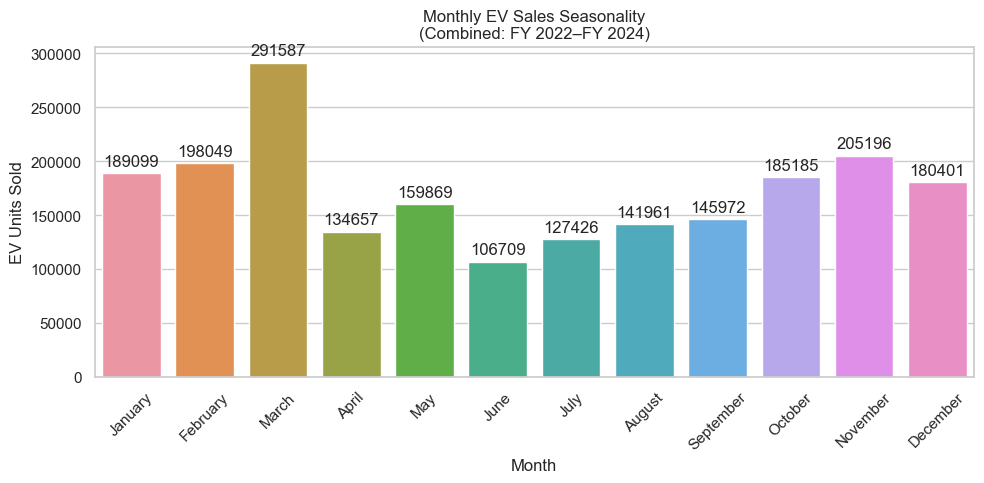

In [101]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=q8_monthly_sales,
    x='month_name',
    y='electric_vehicles_sold'
)

plt.title(
    "Monthly EV Sales Seasonality\n(Combined: FY 2022–FY 2024)"
)
plt.xlabel("Month")
plt.ylabel("EV Units Sold")
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()

# Question 9 
## What is the projected number of EV sales (including 2-wheelers and 4- wheelers) for the top 10 states by penetration rate in 2030, based on the compounded annual growth rate (CAGR) from previous years?


Identify top-10 states by penetration_rate in FY 2024 (use state_df).

Compute annual EV sales (2W + 4W) per state for FY 2022 and FY 2024.

Calculate CAGR for each state (n = 2 years).

Project sales to 2030 using CAGR (years = 2030 − 2024 = 6).

Present a neat table and bar chart.

## Prepare and pick top 10 states by penetration (FY 2024)

In [102]:
q9_base = state_df.copy()

In [103]:
q9_base['fiscal_year'] = q9_base['fiscal_year'].astype(str)

In [104]:
q9_2024 = (
    q9_base[q9_base['fiscal_year'] == '2024']
    .groupby('state', as_index=False)
    .agg({'electric_vehicles_sold':'sum', 'total_vehicles_sold':'sum'})
)
q9_2024['penetration_rate'] = (q9_2024['electric_vehicles_sold'] / q9_2024['total_vehicles_sold']) * 100


In [105]:
q9_top10_states = q9_2024.sort_values('penetration_rate', ascending=False).head(10)['state'].tolist()
q9_top10_states

['Goa',
 'Kerala',
 'Karnataka',
 'Maharashtra',
 'Delhi',
 'Chandigarh',
 'Odisha',
 'Chhattisgarh',
 'Tamil Nadu',
 'Puducherry']

## Compute annual EV sales for 2022 & 2024 (combined 2W + 4W)

### Normalize fiscal_year INSIDE Q9 only

In [106]:
q9_annual = (
    state_df
    .groupby(['state', 'fiscal_year'], as_index=False)
    ['electric_vehicles_sold']
    .sum()
)

In [107]:
q9_annual['fiscal_year'] = q9_annual['fiscal_year'].astype(str) # Ensure fiscal_year is string for filtering

In [108]:
q9_annual_2yrs = q9_annual[
    (q9_annual['fiscal_year'].isin(['2022', '2024'])) &
    (q9_annual['state'].isin(q9_top10_states))
].copy()

In [109]:
q9_annual_2yrs['fiscal_year'].value_counts()

fiscal_year
2022    10
2024    10
Name: count, dtype: int64

## Pivot Table - Q9

In [110]:
q9_pivot = (
    q9_annual_2yrs
    .pivot_table(
        index='state',
        columns='fiscal_year',
        values='electric_vehicles_sold',
        aggfunc='sum'
    )
    .reset_index()
)

q9_pivot

fiscal_year,state,2022,2024
0,Chandigarh,411,2877
1,Chhattisgarh,4534,28540
2,Delhi,16535,46724
3,Goa,1778,10799
4,Karnataka,43111,160989
5,Kerala,13639,73938
6,Maharashtra,48374,197169
7,Odisha,9498,39118
8,Puducherry,734,3098
9,Tamil Nadu,36863,94314


In [111]:
q9_pivot.columns

Index(['state', '2022', '2024'], dtype='object', name='fiscal_year')

In [112]:
q9_pivot = q9_pivot.rename(columns={
    '2022': 'sales_2022',
    '2024': 'sales_2024'
})

## Keep only valid CAGR rows

In [113]:
q9_pivot_valid = q9_pivot.dropna(
    subset=['sales_2022', 'sales_2024']
).copy()

q9_pivot_valid

fiscal_year,state,sales_2022,sales_2024
0,Chandigarh,411,2877
1,Chhattisgarh,4534,28540
2,Delhi,16535,46724
3,Goa,1778,10799
4,Karnataka,43111,160989
5,Kerala,13639,73938
6,Maharashtra,48374,197169
7,Odisha,9498,39118
8,Puducherry,734,3098
9,Tamil Nadu,36863,94314


## Next step (final stretch of Q9)

In [114]:
# CAGR
q9_pivot_valid['cagr_2022_2024 (%)'] = (
    (q9_pivot_valid['sales_2024'] / q9_pivot_valid['sales_2022']) ** 0.5 - 1
) * 100

# Projection to 2030
q9_pivot_valid['projected_sales_2030'] = (
    q9_pivot_valid['sales_2024'] *
    (1 + q9_pivot_valid['cagr_2022_2024 (%)'] / 100) ** 6
).round(0)

In [115]:
q9_result = q9_pivot_valid.sort_values(
    'projected_sales_2030', ascending=False
)

q9_result

fiscal_year,state,sales_2022,sales_2024,cagr_2022_2024 (%),projected_sales_2030
6,Maharashtra,48374,197169,101.889307,13351146.0
5,Kerala,13639,73938,132.831955,11779401.0
4,Karnataka,43111,160989,93.243125,8383406.0
1,Chhattisgarh,4534,28540,150.891661,7118219.0
7,Odisha,9498,39118,102.942141,2732814.0
3,Goa,1778,10799,146.448337,2419574.0
9,Tamil Nadu,36863,94314,59.953130,1579547.0
2,Delhi,16535,46724,68.100075,1054259.0
0,Chandigarh,411,2877,164.575131,986811.0
8,Puducherry,734,3098,105.443628,232936.0


## Visualization 

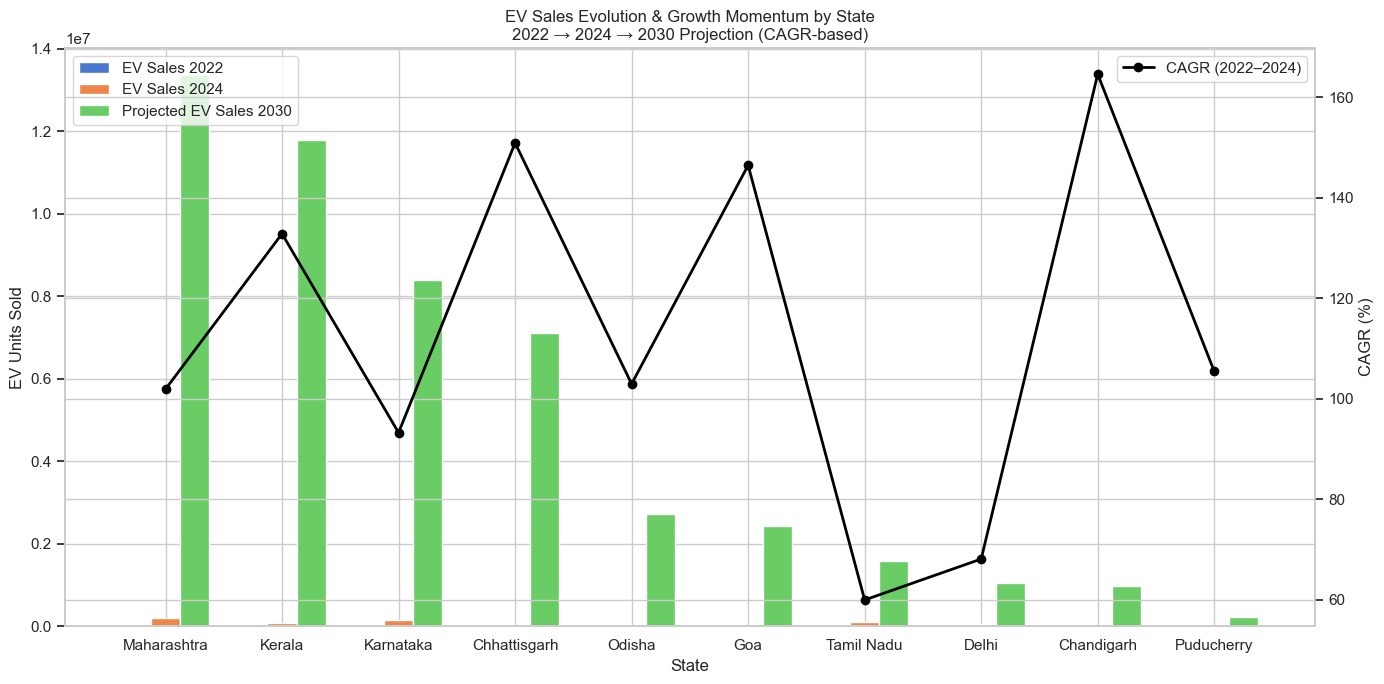

In [116]:
# Sort by projected 2030 sales for clean ordering
q9_viz_df = q9_result.sort_values('projected_sales_2030', ascending=False)

states = q9_viz_df['state']
x = np.arange(len(states))
width = 0.25

plt.figure(figsize=(14, 7))

# Bar plots for sales volumes
plt.bar(x - width, q9_viz_df['sales_2022'], width, label='EV Sales 2022')
plt.bar(x, q9_viz_df['sales_2024'], width, label='EV Sales 2024')
plt.bar(x + width, q9_viz_df['projected_sales_2030'], width, label='Projected EV Sales 2030')

# Secondary axis for CAGR
ax1 = plt.gca()
ax2 = ax1.twinx()

ax2.plot(
    x,
    q9_viz_df['cagr_2022_2024 (%)'],
    color='black',
    marker='o',
    linewidth=2,
    label='CAGR (2022–2024)'
)

# Axis labels
ax1.set_xlabel("State")
ax1.set_ylabel("EV Units Sold")
ax2.set_ylabel("CAGR (%)")

# X ticks
plt.xticks(x, states, rotation=45, ha='right')

# Title
plt.title(
    "EV Sales Evolution & Growth Momentum by State\n"
    "2022 → 2024 → 2030 Projection (CAGR-based)"
)

# Legends
bars_legend = ax1.legend(loc='upper left')
line_legend = ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Question 10 
## Estimate the revenue growth rate of 4-wheeler and 2-wheelers EVs in India for 2022 vs 2024 and 2023 vs 2024, assuming an average unit price. H


| Vehicle Category | Avg Price  |
| ---------------- | ---------- |
| 2-Wheelers       | ₹85,000    |
| 4-Wheelers       | ₹15,00,000 |


Important assumptions:

Prices are constant across years

Revenue growth is driven only by volume growth

All values are estimated, not actual reported revenue

## Aggregate EV sales by year & category

In [117]:
q10_sales = (
    state_df
    .groupby(['fiscal_year', 'vehicle_category'], as_index=False)
    ['electric_vehicles_sold']
    .sum()
)

q10_sales

,fiscal_year,vehicle_category,electric_vehicles_sold
0,2022,2-wheelers,252573
1,2022,4-wheelers,18577
2,2023,2-wheelers,727903
3,2023,4-wheelers,47465
4,2024,2-wheelers,932692
5,2024,4-wheelers,86901


## Map average prices

In [118]:
price_map = {
    '2-wheelers': 85000,
    '4-wheelers': 1500000
}

q10_sales['avg_price'] = q10_sales['vehicle_category'].map(price_map)

## Calculate estimated revenue

In [119]:
q10_sales['estimated_revenue'] = (
    q10_sales['electric_vehicles_sold'] * q10_sales['avg_price']
)

In [120]:
q10_sales['revenue_crores'] = q10_sales['estimated_revenue'] / 1e7       # convert to ₹ Crores for readability
q10_sales

,fiscal_year,vehicle_category,electric_vehicles_sold,avg_price,estimated_revenue,revenue_crores
0,2022,2-wheelers,252573,85000,21468705000,2146.8705
1,2022,4-wheelers,18577,1500000,27865500000,2786.5500
2,2023,2-wheelers,727903,85000,61871755000,6187.1755
3,2023,4-wheelers,47465,1500000,71197500000,7119.7500
4,2024,2-wheelers,932692,85000,79278820000,7927.8820
5,2024,4-wheelers,86901,1500000,130351500000,13035.1500


## Pivot for growth calculations

In [121]:
q10_pivot = q10_sales.pivot(
    index='vehicle_category',
    columns='fiscal_year',
    values='revenue_crores'
).reset_index()

q10_pivot

fiscal_year,vehicle_category,2022,2023,2024
0,2-wheelers,2146.8705,6187.1755,7927.882
1,4-wheelers,2786.5500,7119.7500,13035.150


## Revenue growth calculations

2022 → 2024 growth

In [122]:
q10_pivot['growth_22_24_%'] = (
    (q10_pivot['2024'] / q10_pivot['2022']) - 1
) * 100

2022 → 2024 growth

In [123]:
q10_pivot['growth_23_24_%'] = (
    (q10_pivot['2024'] / q10_pivot['2023']) - 1
) * 100

In [124]:
q10_pivot = q10_pivot.rename(columns={
    '2022': 'revenue_2022',
    '2023': 'revenue_2023',
    '2024': 'revenue_2024'
})

In [125]:
q10_pivot['growth_22_24_%'] = (
    (q10_pivot['revenue_2024'] / q10_pivot['revenue_2022']) - 1
) * 100

q10_pivot['growth_23_24_%'] = (
    (q10_pivot['revenue_2024'] / q10_pivot['revenue_2023']) - 1
) * 100


In [126]:
q10_pivot

fiscal_year,vehicle_category,revenue_2022,revenue_2023,revenue_2024,growth_22_24_%,growth_23_24_%
0,2-wheelers,2146.8705,6187.1755,7927.882,269.276209,28.134106
1,4-wheelers,2786.5500,7119.7500,13035.150,367.788125,83.084378


## Visualization 

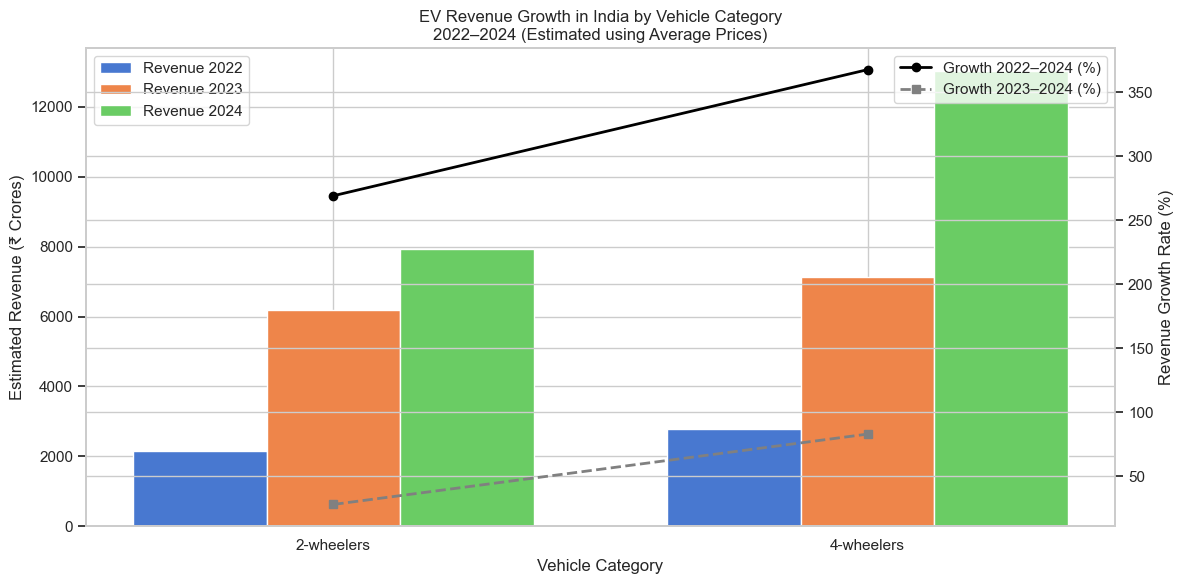

In [127]:
# Data
categories = q10_pivot['vehicle_category']
x = np.arange(len(categories))
width = 0.25

plt.figure(figsize=(12, 6))

# Primary axis (Revenue)
ax1 = plt.gca()

ax1.bar(x - width, q10_pivot['revenue_2022'], width, label='Revenue 2022')
ax1.bar(x, q10_pivot['revenue_2023'], width, label='Revenue 2023')
ax1.bar(x + width, q10_pivot['revenue_2024'], width, label='Revenue 2024')

ax1.set_xlabel("Vehicle Category")
ax1.set_ylabel("Estimated Revenue (₹ Crores)")
ax1.set_xticks(x)
ax1.set_xticklabels(categories)

# Secondary axis (Growth %)
ax2 = ax1.twinx()
ax2.plot(
    x,
    q10_pivot['growth_22_24_%'],
    marker='o',
    linewidth=2,
    color='black',
    label='Growth 2022–2024 (%)'
)
ax2.plot(
    x,
    q10_pivot['growth_23_24_%'],
    marker='s',
    linewidth=2,
    linestyle='--',
    color='gray',
    label='Growth 2023–2024 (%)'
)

ax2.set_ylabel("Revenue Growth Rate (%)")

# Legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Title
plt.title(
    "EV Revenue Growth in India by Vehicle Category\n"
    "2022–2024 (Estimated using Average Prices)"
)

plt.tight_layout()
plt.show()
